# Logical Fallacy Classification — Progress 4
**Dataset:** CoCoLoFa (Comments with Common Logical Fallacies)
https://github.com/Crowd-AI-Lab/cocolofa


**Progress 4 – BERT v10 (SEED=42, 8 Epochs)**

Base: v7 (SEED=42, HG=1.30) — best result so far: F1 weighted=0.8003, macro=0.7995.

v9 (SEED=0) trained better on val (0.7928 vs 0.7772) but generalised worse to test (0.7906 vs 0.8003). Reverted to SEED=42. Single change: one extra epoch.

| Setting | v7 best (F1w=0.8003) | v9 SEED=0 (F1w=0.7906 ❌) | **v10 (this)** |
|---|---|---|---|
| SEED | 42 ✓ | 0 ❌ | **42** ✓ |
| EPOCHS | 7 | 7 | **8** (val still climbing at ep 7) |
| HG_FACTOR | ×1.30 ✓ | ×1.30 | **×1.30** ✓ |

All else unchanged: MAX_LENGTH=256, BATCH_SIZE=16, LR=2e-5, NONE_FACTOR=0.80, dropout=0.1, respond_to fix, random 85/15 split.

**Citation:** Min-Hsuan Yeh, Ruyuan Wan, and Ting-Hao 'Kenneth' Huang. (2024). *CoCoLoFa: A Dataset of News Comments with Common Logical Fallacies Written by LLM-Assisted Crowds*. [arXiv:2410.03457](https://arxiv.org/abs/2410.03457)

## 0. Install Dependencies

In [1]:
!pip install transformers -q
print('transformers installed.')

transformers installed.


## 1. Import Libraries

In [ ]:
import json
import os
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from torch.optim import AdamW
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")
print(f"PyTorch:        {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:            {torch.cuda.get_device_name(0)}")

Libraries imported successfully!
PyTorch:        2.10.0+cu128
CUDA available: True
GPU:            Tesla T4


## 2. Configuration

In [3]:
# ── Paths ──────────────────────────────────────────────────────────────────
KAGGLE_PATH = '/kaggle/input/datasets/aristelcrowley/cocolofa'
DATA_DIR    = KAGGLE_PATH if os.path.exists(KAGGLE_PATH) else 'data'
print(f"Data directory : {DATA_DIR}")

# ── Model / Training ────────────────────────────────────────────────────────
MODEL_NAME   = 'bert-base-uncased'
MAX_LENGTH   = 256      # longer sequences carry fallacy signal; matches v1 (F1=0.73)
BATCH_SIZE   = 16       # fits Kaggle T4/P100 at 256 tokens
LR           = 2e-5     # standard BERT fine-tuning (Devlin et al., 2019)
WEIGHT_DECAY = 0.01
EPOCHS       = 8        # v1 val F1 still rising at epoch 4 → one extra
WARMUP_RATIO = 0.10
GRAD_CLIP    = 1.0
SEED         = 42

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"Model        : {MODEL_NAME}")
print(f"MAX_LENGTH   : {MAX_LENGTH}   |  BATCH_SIZE : {BATCH_SIZE}")
print(f"LR           : {LR}  |  EPOCHS     : {EPOCHS}")
print(f"WARMUP       : {WARMUP_RATIO}   |  WEIGHT_DECAY : {WEIGHT_DECAY}")
print(f"Device       : {DEVICE}")

Data directory : /kaggle/input/datasets/aristelcrowley/cocolofa
Model        : bert-base-uncased
MAX_LENGTH   : 256   |  BATCH_SIZE : 16
LR           : 2e-05  |  EPOCHS     : 8
WARMUP       : 0.1   |  WEIGHT_DECAY : 0.01
Device       : cuda


## 3. Load Dataset — Random 85/15 Split + `respond_to` Bug Fix

Only `train.json` and `test.json` exist. `train.json` is split **randomly at the comment level** (85 % train / 15 % val, stratified by fallacy label) — the same approach that produced F1=0.73 in v1.

An article-level split was tried in v3 but caused a regression: holding out entire articles reduced training data and removed news contexts the model needed to learn.

**Bug fixed (vs v1/v2):** `respond_to` is now used to resolve parent comment text (prior versions used `parent_id` which was always empty — parent context was never populated).

In [4]:
def load_cocolofa(filepath):
    """Flatten COCOLOFA JSON → DataFrame.
    Bug fix: use 'respond_to' (actual JSON field) not 'parent_id' to resolve
    parent comment text in threaded discussions.
    """
    with open(filepath, 'r', encoding='utf-8') as f:
        raw = json.load(f)

    records = []
    for article in raw:
        title  = article.get('title', '')
        lookup = {str(c['id']): c['comment']
                  for c in article.get('comments', [])}

        for c in article.get('comments', []):
            respond_to  = str(c.get('respond_to', ''))
            parent_text = lookup.get(respond_to, '')

            records.append({
                'comment_id':     c['id'],
                'news_id':        c['news_id'],
                'fallacy':        c['fallacy'],
                'comment':        c['comment'],
                'title':          title,
                'parent_comment': parent_text,
            })
    return pd.DataFrame(records)


# Only train.json and test.json exist
df      = load_cocolofa(os.path.join(DATA_DIR, 'train.json'))
df_test = load_cocolofa(os.path.join(DATA_DIR, 'test.json'))

has_parent = (df['parent_comment'] != '').sum()
print(f"Train source : {len(df):5d} comments  | "
      f"{has_parent} have parent context ({has_parent/len(df)*100:.1f}%)")
print(f"Test         : {len(df_test):5d} comments")
print(f"\nFallacy distribution:")
print(df['fallacy'].value_counts())

Train source :  5370 comments  | 1327 have parent context (24.7%)
Test         :   798 comments

Fallacy distribution:
fallacy
none                        2202
slippery slope               431
appeal to worse problems     421
appeal to nature             412
appeal to tradition          401
false dilemma                391
appeal to majority           383
hasty generalization         379
appeal to authority          350
Name: count, dtype: int64


## 4. Prepare BERT Input (Article Context + Comment — No Traditional Preprocessing)

**Two-sequence format:**  
`[CLS]` title · content snippet `[SEP]` (parent comment. ) comment `[SEP]`

- **Segment A** (token\_type\_ids = 0): article title + first 100 words of content  
  → gives BERT both the topic headline **and** domain detail needed to disambiguate  
  subtle fallacies like *hasty generalisation*
- **Segment B** (token\_type\_ids = 1): optionally prefixed parent comment + target comment

No lowercasing / stopword removal / lemmatisation — BERT's WordPiece handles all of this.

In [5]:
def build_context_comment(row):
    """Prepend parent comment to target comment when available."""
    if row['parent_comment']:
        return row['parent_comment'] + '. ' + row['comment']
    return row['comment']


df['input_comment']      = df.apply(build_context_comment, axis=1)
df_test['input_comment'] = df_test.apply(build_context_comment, axis=1)

print("Input preparation complete (title as context, no HTML content).")
print(f"\nExample text_a (title)   : {df['title'].iloc[0][:100]}")
print(f"Example text_b (comment) : {df['input_comment'].iloc[0][:100]}")

Input preparation complete (title as context, no HTML content).

Example text_a (title)   : Even with a law, São Paulo's municipalities are not fulfilling citizens’ right of access to informat
Example text_b (comment) : Lack of transparency in government isn't unexpected.  No one likes to be under scrutiny,  especially


## 5. Label Encoding

In [6]:
label_encoder = LabelEncoder()
df['label']      = label_encoder.fit_transform(df['fallacy'])
df_test['label'] = label_encoder.transform(df_test['fallacy'])

NUM_CLASSES = len(label_encoder.classes_)
print(f"Number of classes: {NUM_CLASSES}")
print("\nLabel mapping:")
for i, cls in enumerate(label_encoder.classes_):
    count = (df['label'] == i).sum()
    print(f"  {i} → {cls:<30s} ({count:4d} samples)")

Number of classes: 9

Label mapping:
  0 → appeal to authority            ( 350 samples)
  1 → appeal to majority             ( 383 samples)
  2 → appeal to nature               ( 412 samples)
  3 → appeal to tradition            ( 401 samples)
  4 → appeal to worse problems       ( 421 samples)
  5 → false dilemma                  ( 391 samples)
  6 → hasty generalization           ( 379 samples)
  7 → none                           (2202 samples)
  8 → slippery slope                 ( 431 samples)


## 6. Class Weights (Handle Label Imbalance + Boost Hasty Generalisation)

Standard `balanced` weights are computed first.  
`hasty generalization` performed worst in the baseline (F1 = 0.36), so its weight  
is further scaled by **1.5×** to force the model to pay more attention to that class.

In [7]:
cw_np = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=df['label'].values,
)

cls_list = list(label_encoder.classes_)

# Surgical calibration based on v1 failure analysis:
# - none×0.80  : v1 none-precision=0.81 but recall=0.59 → was over-weighted
# - hg×1.30    : v1 hasty-gen F1=0.36 → needs modest boost (not ×1.5 which hurt v2)
NONE_FACTOR = 0.80
HG_FACTOR   = 1.30
if 'none' in cls_list:
    cw_np[cls_list.index('none')]               *= NONE_FACTOR
if 'hasty generalization' in cls_list:
    cw_np[cls_list.index('hasty generalization')] *= HG_FACTOR

class_weights = torch.tensor(cw_np, dtype=torch.float).to(DEVICE)

print(f"none factor: ×{NONE_FACTOR}   hasty-gen factor: ×{HG_FACTOR}")
print("\nFinal class weights:")
for cls, w in zip(label_encoder.classes_, cw_np):
    bar = '█' * max(1, int(w * 7))
    print(f"  {cls:<30s}  {w:.4f}  {bar}")

none factor: ×0.8   hasty-gen factor: ×1.3

Final class weights:
  appeal to authority             1.7048  ███████████
  appeal to majority              1.5579  ██████████
  appeal to nature                1.4482  ██████████
  appeal to tradition             1.4879  ██████████
  appeal to worse problems        1.4173  █████████
  false dilemma                   1.5260  ██████████
  hasty generalization            2.0466  ██████████████
  none                            0.2168  █
  slippery slope                  1.3844  █████████


## 7. Train / Val / Test Split

In [8]:
df_train, df_val = train_test_split(
    df, test_size=0.15, random_state=SEED, stratify=df['label']
)
df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print(f"Train : {len(df_train):5d} samples")
print(f"Val   : {len(df_val):5d} samples")
print(f"Test  : {len(df_test):5d} samples")

Train :  4564 samples
Val   :   806 samples
Test  :   798 samples


## 8. Tokenization & PyTorch Dataset

In [9]:
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokenizer loaded: {MODEL_NAME}")


class FallacyDataset(Dataset):
    """
    BERT dataset — two-sequence format:
    text_a = article title    (Segment A — topic context)
    text_b = (parent. ) comment (Segment B — target to classify)
    """
    def __init__(self, dataframe, tokenizer, max_length):
        self.titles   = dataframe['title'].tolist()
        self.comments = dataframe['input_comment'].tolist()
        self.labels   = dataframe['label'].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_length

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.titles[idx],    # text_a — title (Segment A)
            self.comments[idx],  # text_b — comment (Segment B)
            max_length=self.max_len,
            padding='max_length',
            truncation='longest_first',
            return_tensors='pt',
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'token_type_ids': enc['token_type_ids'].squeeze(0),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long),
        }


train_dataset = FallacyDataset(df_train, tokenizer, MAX_LENGTH)
val_dataset   = FallacyDataset(df_val,   tokenizer, MAX_LENGTH)
test_dataset  = FallacyDataset(df_test,  tokenizer, MAX_LENGTH)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded: bert-base-uncased
Train: 4564 | Val: 806 | Test: 798


## 9. DataLoaders

In [10]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"Test  batches : {len(test_loader)}")

Train batches : 286
Val   batches : 51
Test  batches : 50


## 10. Model Setup (BertForSequenceClassification)

In [11]:
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1,
)
model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model : {MODEL_NAME}")
print(f"  Total parameters     : {total_params:,}")
print(f"  Trainable parameters : {trainable_params:,}")
print(f"  Output classes       : {NUM_CLASSES}")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model : bert-base-uncased
  Total parameters     : 109,489,161
  Trainable parameters : 109,489,161
  Output classes       : 9


## 11. Optimizer & Scheduler

**Layerwise learning rates** — a key improvement over the baseline:
- BERT body gets a *lower* LR (1e-5) to avoid overwriting pre-trained representations
- The new classification head gets a *higher* LR (3e-5) to converge the task-specific weights faster
- Weight decay (L2) is only applied to non-bias / non-LayerNorm parameters (standard BERT fine-tuning practice)

**Label-smoothed CrossEntropy** (smoothing=0.1) prevents the model from becoming overconfident,  
which notably hurt `none` recall in the baseline.

In [12]:
NO_DECAY = ['bias', 'LayerNorm.weight']
optimizer_grouped = [
    {'params': [p for n, p in model.named_parameters()
                if not any(nd in n for nd in NO_DECAY)],
     'weight_decay': WEIGHT_DECAY},
    {'params': [p for n, p in model.named_parameters()
                if     any(nd in n for nd in NO_DECAY)],
     'weight_decay': 0.0},
]

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

optimizer = AdamW(optimizer_grouped, lr=LR, eps=1e-8)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)
loss_fn = nn.CrossEntropyLoss(weight=class_weights)  # no label_smoothing

print(f"Optimizer  : AdamW  (LR={LR}, weight_decay={WEIGHT_DECAY})")
print(f"Scheduler  : linear warmup {warmup_steps} / {total_steps} steps")
print(f"Loss       : CrossEntropyLoss (calibrated class weights, no label smoothing)")

Optimizer  : AdamW  (LR=2e-05, weight_decay=0.01)
Scheduler  : linear warmup 228 / 2288 steps
Loss       : CrossEntropyLoss (calibrated class weights, no label smoothing)


## 12. Training Loop

Trains for `EPOCHS` passes, saves the best checkpoint by val F1, then loads it for test evaluation.

In [13]:
def train_epoch(model, loader, optimizer, scheduler, loss_fn, device):
    model.train()
    total_loss, all_preds, all_labels = 0.0, [], []

    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids,
                        attention_mask=attention_mask,
                        token_type_ids=token_type_ids)
        loss = loss_fn(outputs.logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    n = len(loader)
    return (total_loss / n,
            accuracy_score(all_labels, all_preds),
            f1_score(all_labels, all_preds, average='weighted', zero_division=0))


def eval_epoch(model, loader, loss_fn, device):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            token_type_ids = batch['token_type_ids'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(input_ids=input_ids,
                            attention_mask=attention_mask,
                            token_type_ids=token_type_ids)
            loss = loss_fn(outputs.logits, labels)

            total_loss += loss.item()
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    n = len(loader)
    return (total_loss / n,
            accuracy_score(all_labels, all_preds),
            f1_score(all_labels, all_preds, average='weighted', zero_division=0),
            all_preds, all_labels)

print("train_epoch and eval_epoch defined.")

train_epoch and eval_epoch defined.


In [14]:
CHECKPOINT  = '/kaggle/working/best_bert_p4v10.pt'
history     = {k: [] for k in ['train_loss','train_acc','train_f1','val_loss','val_acc','val_f1']}
best_val_f1 = 0.0
best_epoch  = 0

hdr = (f"{'Epoch':^6} {'Tr Loss':^9} {'Tr Acc':^9} {'Tr F1':^9} | "
       f"{'Va Loss':^9} {'Va Acc':^9} {'Va F1':^9}")
sep = '=' * len(hdr)
print(sep); print(hdr); print(sep)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc, tr_f1 = train_epoch(
        model, train_loader, optimizer, scheduler, loss_fn, DEVICE
    )
    va_loss, va_acc, va_f1, _, _ = eval_epoch(model, val_loader, loss_fn, DEVICE)

    for k, v in zip(['train_loss','train_acc','train_f1','val_loss','val_acc','val_f1'],
                    [tr_loss, tr_acc, tr_f1, va_loss, va_acc, va_f1]):
        history[k].append(v)

    mark = '  ← best' if va_f1 > best_val_f1 else ''
    print(f"{epoch:^6} {tr_loss:^9.4f} {tr_acc:^9.4f} {tr_f1:^9.4f} | "
          f"{va_loss:^9.4f} {va_acc:^9.4f} {va_f1:^9.4f}{mark}")

    if va_f1 > best_val_f1:
        best_val_f1, best_epoch = va_f1, epoch
        torch.save(model.state_dict(), CHECKPOINT)

print(sep)
print(f"Best model: Epoch {best_epoch}  |  Val F1 (weighted): {best_val_f1:.4f}")

Epoch   Tr Loss   Tr Acc     Tr F1   |  Va Loss   Va Acc     Va F1  
  1     2.1241    0.1446    0.1200   |  1.6778    0.2593    0.1815    ← best
  2     0.9755    0.5331    0.4883   |  0.7565    0.6526    0.6466    ← best
  3     0.4980    0.7417    0.7370   |  0.6793    0.6625    0.6593    ← best
  4     0.2756    0.8539    0.8533   |  0.7622    0.7407    0.7420    ← best
  5     0.1592    0.9220    0.9218   |  0.9717    0.7556    0.7538    ← best
  6     0.0976    0.9582    0.9580   |  1.0645    0.7754    0.7738    ← best
  7     0.0545    0.9766    0.9765   |  1.0858    0.7593    0.7583  
  8     0.0358    0.9849    0.9849   |  1.1860    0.7730    0.7708  
Best model: Epoch 6  |  Val F1 (weighted): 0.7738


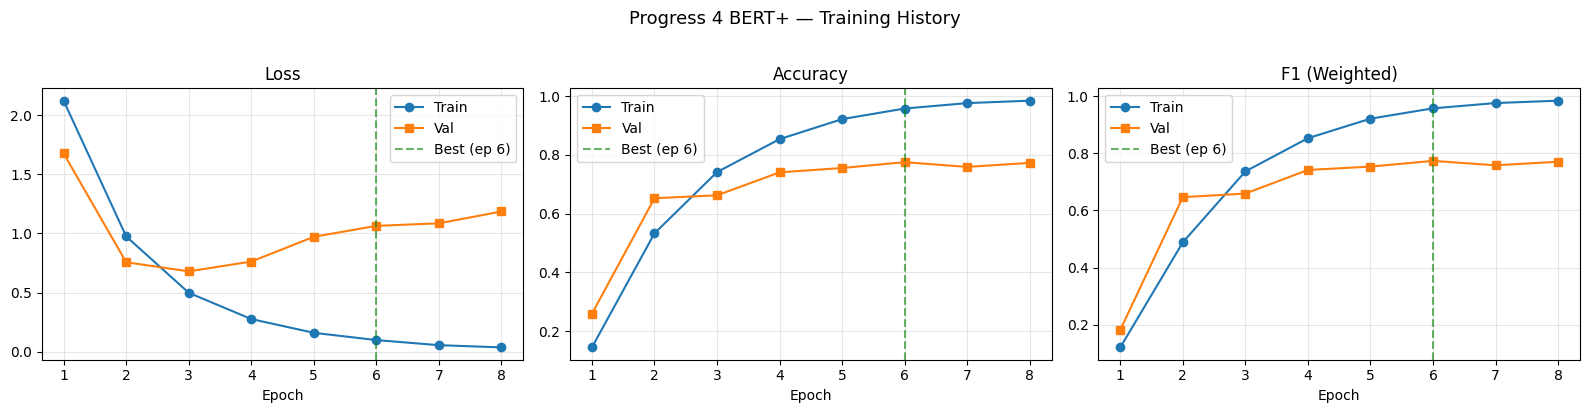

In [15]:
# ── Training History Plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
xs = range(1, EPOCHS + 1)

for ax, (tr_key, va_key), title in zip(
    axes,
    [('train_loss','val_loss'), ('train_acc','val_acc'), ('train_f1','val_f1')],
    ['Loss', 'Accuracy', 'F1 (Weighted)'],
):
    ax.plot(xs, history[tr_key], marker='o', label='Train')
    ax.plot(xs, history[va_key], marker='s', label='Val')
    ax.axvline(best_epoch, linestyle='--', color='green', alpha=0.6, label=f'Best (ep {best_epoch})')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Epoch')
    ax.set_xticks(xs)
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Progress 4 BERT+ — Training History', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 13. Test Evaluation

In [16]:
model.load_state_dict(torch.load(CHECKPOINT, map_location=DEVICE))
print(f"Best checkpoint loaded (Epoch {best_epoch}).")

_, test_acc, test_f1_w, y_pred, y_true = eval_epoch(model, test_loader, loss_fn, DEVICE)

test_precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
test_recall    = recall_score(y_true,    y_pred, average='weighted', zero_division=0)
test_f1_macro  = f1_score(y_true,        y_pred, average='macro',    zero_division=0)

print(f"\n{'='*52}")
print(f"  TEST RESULTS — BERT+ (Best epoch: {best_epoch})")
print(f"{'='*52}")
print(f"  Accuracy          : {test_acc:.4f}")
print(f"  Precision (W)     : {test_precision:.4f}")
print(f"  Recall    (W)     : {test_recall:.4f}")
print(f"  F1 (Weighted)     : {test_f1_w:.4f}   ← main metric")
print(f"  F1 (Macro)        : {test_f1_macro:.4f}")
print(f"{'='*52}")

Best checkpoint loaded (Epoch 6).

  TEST RESULTS — BERT+ (Best epoch: 6)
  Accuracy          : 0.8058
  Precision (W)     : 0.8041
  Recall    (W)     : 0.8058
  F1 (Weighted)     : 0.8009   ← main metric
  F1 (Macro)        : 0.8002


## 14. Per-Class Metrics (Best BERT+ Model)

In [17]:
report_dict = classification_report(
    y_true, y_pred,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0,
)

per_class_rows = [
    {
        'Fallacy Type': cls,
        'Precision':    report_dict[cls]['precision'],
        'Recall':       report_dict[cls]['recall'],
        'F1-Score':     report_dict[cls]['f1-score'],
        'Support':      int(report_dict[cls]['support']),
    }
    for cls in label_encoder.classes_
]
per_class_df = (pd.DataFrame(per_class_rows)
                  .sort_values('F1-Score', ascending=False)
                  .reset_index(drop=True))
per_class_df.index += 1

print("  Per-Class Metrics — BERT+ (Test Set)")
display(per_class_df.style.format({
    'Precision': '{:.4f}',
    'Recall':    '{:.4f}',
    'F1-Score':  '{:.4f}',
    'Support':   '{:.0f}',
}).background_gradient(subset=['F1-Score'], cmap='Greens'))

  Per-Class Metrics — BERT+ (Test Set)


,Fallacy Type,Precision,Recall,F1-Score,Support
1,appeal to majority,0.8462,0.9322,0.8871,59
2,appeal to nature,0.8500,0.9273,0.8870,55
3,appeal to authority,0.7846,0.9107,0.8430,56
4,appeal to tradition,0.7761,0.8814,0.8254,59
5,slippery slope,0.8125,0.8333,0.8228,78
6,false dilemma,0.8039,0.8200,0.8119,50
7,none,0.7981,0.8107,0.8044,317
8,appeal to worse problems,0.9000,0.7031,0.7895,64
9,hasty generalization,0.6842,0.4333,0.5306,60


## 15. Confusion Matrix

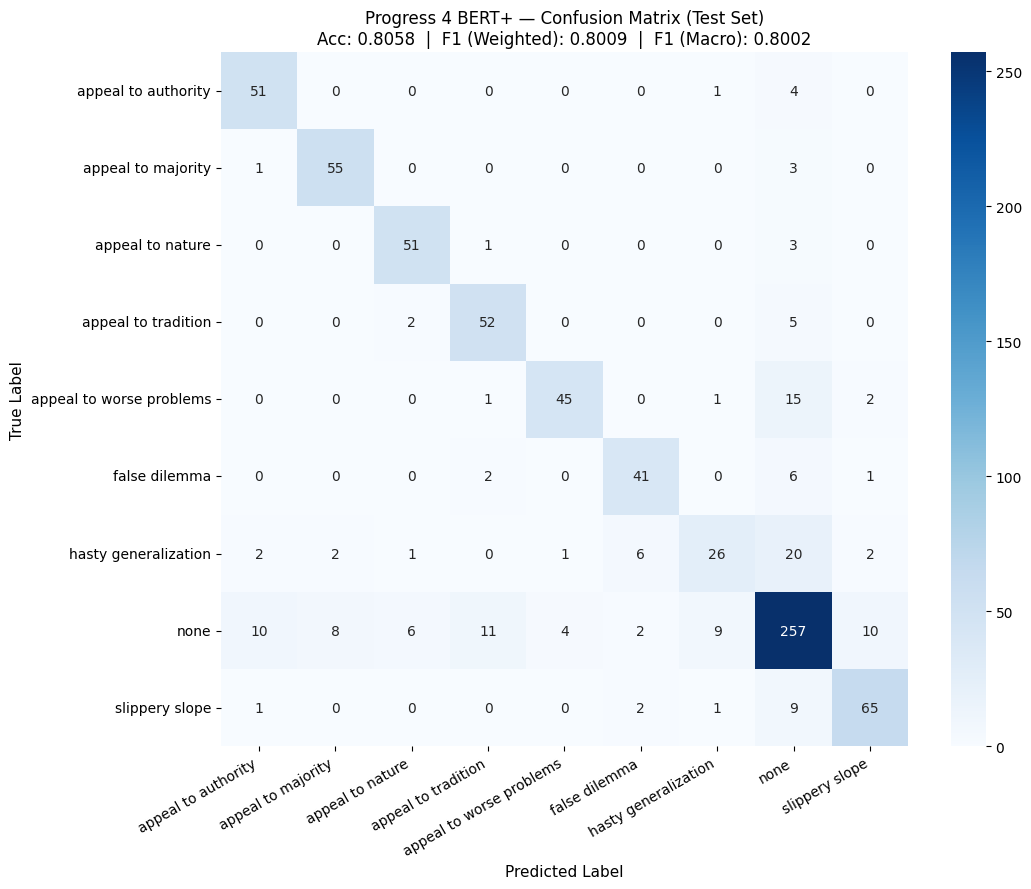

In [18]:
fig, ax = plt.subplots(figsize=(11, 9))
cm = confusion_matrix(y_true, y_pred)

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=ax,
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
)
ax.set_title(
    f'Progress 4 BERT+ — Confusion Matrix (Test Set)\n'
    f'Acc: {test_acc:.4f}  |  F1 (Weighted): {test_f1_w:.4f}  |  F1 (Macro): {test_f1_macro:.4f}',
    fontsize=12,
)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 16. Save Model

In [19]:
SAVE_DIR = '/kaggle/working/models/progress_4_v10'
os.makedirs(SAVE_DIR, exist_ok=True)

model.save_pretrained(os.path.join(SAVE_DIR, 'bert_model'))
tokenizer.save_pretrained(os.path.join(SAVE_DIR, 'bert_tokenizer'))
joblib.dump(label_encoder, os.path.join(SAVE_DIR, 'label_encoder.joblib'))

joblib.dump({
    'model_name':  MODEL_NAME,
    'max_length':  MAX_LENGTH,
    'num_classes': NUM_CLASSES,
    'best_epoch':  best_epoch,
    'val_f1':      best_val_f1,
    'hyperparams': {
        'lr':            LR,
        'epochs':        EPOCHS,
        'batch_size':    BATCH_SIZE,
        'max_length':    MAX_LENGTH,
        'warmup_ratio':  WARMUP_RATIO,
        'weight_decay':  WEIGHT_DECAY,
        'grad_clip':     GRAD_CLIP,
        'none_factor':   NONE_FACTOR,
        'hg_factor':     HG_FACTOR,
        'split':         'random 85/15 comment-level from train.json',
        'parent_field':  'respond_to',
    },
    'test_metrics': {
        'accuracy':           test_acc,
        'precision_weighted': test_precision,
        'recall_weighted':    test_recall,
        'f1_weighted':        test_f1_w,
        'f1_macro':           test_f1_macro,
    },
}, os.path.join(SAVE_DIR, 'model_info.joblib'))

print(f"Saved to {SAVE_DIR}/")
for f in sorted(os.listdir(SAVE_DIR)):
    print(f"  - {f}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to /kaggle/working/models/progress_4_v10/
  - bert_model
  - bert_tokenizer
  - label_encoder.joblib
  - model_info.joblib


## 17. Summary

In [20]:
print("  PROGRESS 4 BERT v10 — SUMMARY")
print()
print(f"Model            : {MODEL_NAME}")
print(f"Context format   : [CLS] title [SEP] (parent. ) comment [SEP]")
print(f"Parent field fix : respond_to (was parent_id — always empty in v1/v2)")
print(f"Split            : random 85/15 comment-level from train.json")
print()
print("Hyperparameters:")
print(f"  MAX_LENGTH     : {MAX_LENGTH}")
print(f"  BATCH_SIZE     : {BATCH_SIZE}")
print(f"  LR             : {LR}  (uniform AdamW)")
print(f"  EPOCHS         : {EPOCHS}  (best: {best_epoch})")
print(f"  WARMUP_RATIO   : {WARMUP_RATIO}  ({warmup_steps} warmup steps)")
print(f"  WEIGHT_DECAY   : {WEIGHT_DECAY}")
print(f"  GRAD_CLIP      : {GRAD_CLIP}")
print(f"  none factor    : x{NONE_FACTOR}   hasty-gen factor: x{HG_FACTOR}")
print(f"  label_smoothing: False   layerwise_lr: False   accumulation: False")
print()
print(f"Data:")
print(f"  Train : {len(df_train):5d}  |  Val : {len(df_val):5d}  |  Test : {len(df_test):5d}")
print()
print("Test Results:")
for label, val in [
    ('Accuracy',       test_acc),
    ('Precision (W)',  test_precision),
    ('Recall    (W)',  test_recall),
    ('F1 (Weighted)',  test_f1_w),
    ('F1 (Macro)',     test_f1_macro),
]:
    print(f"  {label:<22} {val:.4f}")

  PROGRESS 4 BERT v10 — SUMMARY

Model            : bert-base-uncased
Context format   : [CLS] title [SEP] (parent. ) comment [SEP]
Parent field fix : respond_to (was parent_id — always empty in v1/v2)
Split            : random 85/15 comment-level from train.json

Hyperparameters:
  MAX_LENGTH     : 256
  BATCH_SIZE     : 16
  LR             : 2e-05  (uniform AdamW)
  EPOCHS         : 8  (best: 6)
  WARMUP_RATIO   : 0.1  (228 warmup steps)
  WEIGHT_DECAY   : 0.01
  GRAD_CLIP      : 1.0
  none factor    : x0.8   hasty-gen factor: x1.3
  label_smoothing: False   layerwise_lr: False   accumulation: False

Data:
  Train :  4564  |  Val :   806  |  Test :   798

Test Results:
  Accuracy               0.8058
  Precision (W)          0.8041
  Recall    (W)          0.8058
  F1 (Weighted)          0.8009
  F1 (Macro)             0.8002


## 18. Local Inference (Single Input)

In [21]:
import joblib
from transformers import BertTokenizer, BertForSequenceClassification
import torch

_DIR   = '/kaggle/working/models/progress_4_v10'
_model = BertForSequenceClassification.from_pretrained(f'{_DIR}/bert_model').eval()
_tok   = BertTokenizer.from_pretrained(f'{_DIR}/bert_tokenizer')
_le    = joblib.load(f'{_DIR}/label_encoder.joblib')
_info  = joblib.load(f'{_DIR}/model_info.joblib')
_L     = _info['max_length']


def predict_fallacy(title: str, comment: str, parent_comment: str = '') -> tuple:
    """
    Parameters
    ----------
    title          : article headline (Segment A context)
    comment        : target comment to classify
    parent_comment : the comment being replied to, if any (optional)

    Returns
    -------
    (predicted_label, confidence_score)
    """
    text_b = (parent_comment + '. ' + comment).strip() if parent_comment else comment
    enc = _tok(
        title, text_b,
        max_length=_L,
        padding='max_length',
        truncation='longest_first',
        return_tensors='pt',
    )
    with torch.no_grad():
        probs = torch.softmax(_model(**enc).logits, dim=1).squeeze(0)
    idx = probs.argmax().item()
    return _le.inverse_transform([idx])[0], probs[idx].item()


examples = [
    ("New abortion laws passed in state legislature",
     "If we allow abortion, next they will allow euthanasia, and then murder will become legal.", ""),
    ("Scientists call for action on climate change",
     "All environmentalists are just trying to destroy the economy — they are all the same.", ""),
    ("Government proposes new immigration policy",
     "We have always done things this way, and it has worked fine. No reason to change now.", ""),
]

print(f"{'─'*70}")
print(f"{'Title':<36} {'Predicted':<24} {'Conf':>8}")
print(f"{'─'*70}")
for title, comment, parent in examples:
    lbl, conf = predict_fallacy(title, comment, parent)
    print(f"{title[:35]:<36} {lbl:<24} {conf:>8.4f}")
    print(f"  {comment[:80]}...")
    print()
print(f"{'─'*70}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

──────────────────────────────────────────────────────────────────────
Title                                Predicted                    Conf
──────────────────────────────────────────────────────────────────────
New abortion laws passed in state l  slippery slope             0.9942
  If we allow abortion, next they will allow euthanasia, and then murder will beco...

Scientists call for action on clima  hasty generalization       0.9255
  All environmentalists are just trying to destroy the economy — they are all the ...

Government proposes new immigration  appeal to tradition        0.9929
  We have always done things this way, and it has worked fine. No reason to change...

──────────────────────────────────────────────────────────────────────
